In [1]:
#Figures, in order:
# Heatmap of shared Neanderthal and denisovan ancestry (if time, ancestry-aware sharing which would be supplemental) (MAIN FIG)
# Proportions of EUR admixture + sharing averages per AMR pops
# Recovered archaic ancestry per pop (Denisovan, Neand, total archaic)
# ancestry-specific recovered (MAIN FIG)
# simulations recovered (no need to invoke selection or anything)
# Shared archaic versus IBD (since emilia likes that plot IG) (MAIN FIG)
# Boxplots of IBD in each of the relevant pops for real data
# then boxplots of IBD in each of the relevant pops for sims (standard, not donor models; would expect more IBD in real data methinks)
# European vs IBD (include confidence intervals) (MAIN FIG)
# African vs IBD
# Indigenous vs IBD
# ancestry-specific PCA (needs fixing) (MAIN FIG)
# sims with donor model per admix pop
# sims with different models per MXL admixture props (MAIN FIG)
# mtDNA and Y haplogroup stuff

# We start with overall sharing measures within and between all populations

## Here we have heatmaps + sharing amounts within each population

In [2]:
import gzip
import pandas as pd
import tarfile
import matplotlib.pyplot as plt
import os
import numpy as np
# import seaborn as sns
from scipy import stats
import itertools
from upsetplot import UpSet, generate_counts, plot, from_memberships
from intervaltree import IntervalTree
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
import statistics
import re
from collections import defaultdict
from itertools import combinations
from scipy.stats import mannwhitneyu
import pandas as pd
import statsmodels.stats.multitest as smm
from statsmodels.stats.multitest import multipletests
import matplotlib.ticker as mticker

In [3]:
### filtering laurits hmmix calls
hmmix = pd.read_csv('/users/akuntzle/IBD_archaic_shared/data/hmmix_output/hg38_1000g_segments.txt', sep=r"\s+")
hmmix[(hmmix['mean_prob'] >= 0.80) & (hmmix['ND_type'] == 'Neanderthal')].to_csv('/users/akuntzle/IBD_archaic_shared/data/hmmix_output/hmmix_neanderthal_filtered.csv',index=None)
hmmix[(hmmix['mean_prob'] >= 0.80) & (hmmix['ND_type'] == 'Denisova')].to_csv('/users/akuntzle/IBD_archaic_shared/data/hmmix_output/hmmix_denisovan_filtered.csv',index=None)
hmmix[(hmmix['mean_prob'] >= 0.80)].to_csv('/users/akuntzle/IBD_archaic_shared/data/hmmix_output/hmmix_filtered.csv',index=None)

In [4]:
sub_pops = ['CHB', 'JPT', 'CHS', 'CDX', 'KHV', #3000
            'CEU', 'TSI', 'GBR', 'FIN', 'IBS',  #2000
            'GIH', 'PJL', 'BEB', 'STU', 'ITU', #3000
            'MXL', 'PEL', 'PUR', 'CLM']

In [21]:
# To get pairwise intersections, run /users/akuntzle/IBD_archaic_shared/code/pairwise_all.script
# which uses pairwise_hmmix.sh and pairwise_within_hmmix.sh

In [5]:
def get_averages_list(filenames):
    all_integers = []
    total_no_share = 0

    for filename in filenames:
        with open(filename, 'r') as file:
            for line in file:
                line = line.strip().split()
                if len(line) < 3:
                    continue  # skip malformed lines

                id1, id2, num_intersect = line[0], line[1], int(line[2])

                if 'sorted' in id1 and 'sorted' in id2:
                    all_integers.append(num_intersect)
                    if num_intersect == 0:
                        total_no_share += 1

    if not all_integers:
        return 0, 0, 0, 0  # handle case where nothing matched

    nonzero = [x for x in all_integers if x > 0]
    avg_all = sum(all_integers) / len(all_integers)
    avg_cond_on_share = sum(nonzero) / len(nonzero) if nonzero else 0
    print(avg_all)

    return len(all_integers), avg_all, total_no_share, avg_cond_on_share


In [6]:
#returns # of pairs, average of all pairs, # of pairs that have no sharing, average of pairs conditioned on sharing
#currently only works for laurits's stuff - need to re-run the pairwise comparisons with the sorted files
def get_averages(filename):
    with open(filename, 'r') as file:
        integers = []
        no_share = 0
        for line in file:
            line = line.strip().split()
            id1 = line[0]
            id2 = line[1]
            if len(line) == 3:
                num_intersect = int(line[2])
            if 'sorted' in id1 and 'sorted' in id2:
                integers.append(num_intersect)
                if num_intersect == 0:
                    no_share += 1
        nonzero = [x for x in integers if x > 0]
        avg_cond_on_share = sum(nonzero) / len(nonzero) if nonzero else 0
        
        return len(integers), sum(integers)/len(integers), no_share, avg_cond_on_share
            

In [7]:
def get_comparisons(folder):
    compared_hmm = []
    dire = f"/users/akuntzle/data/akuntzle/hmmix_output/{folder}/"
    for i in range(len(sub_pops)):
        for j in range(i+1, len(sub_pops)):
            # pot_path = f"{dire}{sub_pops[i]}_{sub_pops[j]}_pairwise_average_sharing.txt"
            pot_path=f"{dire}{sub_pops[i]}_{{{sub_pops[j]}}}.txt"
            if os.path.isfile(pot_path):
                path = pot_path
            else:
                path = f"{dire}{sub_pops[j]}_{{{sub_pops[i]}}}.txt"
            with open(path, 'r') as file:
                num_pairs, total_avg, num_pairs_no_share, cond_avg = get_averages(path)
                compared_hmm.append(total_avg)
    
    # Create a dictionary for the pairwise comparison indices
    pairs = []
    for i in range(len(sub_pops)):
        for j in range(i + 1, len(sub_pops)):
            pairs.append((i, j))
            
    compared_hmm_2D = np.zeros((len(sub_pops), len(sub_pops)))
    
    for k, (i, j) in enumerate(pairs):
        compared_hmm_2D[i, j] = np.asarray(compared_hmm[k])
        compared_hmm_2D[j, i] = np.asarray(compared_hmm[k])
    
    for i in range(len(sub_pops)):
        diagonal_path = f"{dire}all_{sub_pops[i]}.txt"
        if os.path.isfile(diagonal_path):
            with open(diagonal_path, 'r') as file:
                num_pairs, total_avg, num_pairs_no_share, cond_avg = get_averages(diagonal_path)
                compared_hmm_2D[i, i] = float(total_avg)
    # print(compared_hmm_2D)
    return compared_hmm_2D

In [8]:
from matplotlib.ticker import ScalarFormatter

def plot_comparisons(compared_hmm_2D, min_val, max_val, archaic):
    fig, ax = plt.subplots()

    # Lower triangle mask
    lower_mask = np.tri(compared_hmm_2D.shape[0], compared_hmm_2D.shape[1], k=-1)
    upper_mask = lower_mask.T
    compared_hmm_2D_mask = np.ma.array(compared_hmm_2D, mask=upper_mask)

    # Use actual scale (important!)
    im = ax.imshow(compared_hmm_2D_mask, cmap='YlGn',
                   vmin=min_val, vmax=max_val)

    # Ticks
    ax.set_xticks(range(len(sub_pops)), labels=sub_pops,
                  rotation=45, ha="right", rotation_mode="anchor", fontsize=12)
    ax.set_yticks(range(len(sub_pops)), labels=sub_pops, fontsize=12)

        # Colorbar with scientific notation
    cbar = fig.colorbar(im, ax=ax)
    
    cbar.ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}×10⁶")
    )

    # formatter = ScalarFormatter(useMathText=True)
    # formatter.set_scientific(True)
    # formatter.set_powerlimits((0, 0))  # always use scientific notation
    # cbar.ax.yaxis.set_major_formatter(formatter)

    fig.tight_layout()

    plt.title(archaic, fontsize=16)
    plt.savefig(f'/users/akuntzle/IBD_archaic_shared/figures/{archaic}_shared_heatmap.png')


    for i in range(compared_hmm_2D.shape[0]):
        for j in range(compared_hmm_2D.shape[1]):
            # Skip masked (upper triangle)
            if not compared_hmm_2D_mask.mask[i, j]:
                x_label = sub_pops[j]
                y_label = sub_pops[i]
                val = compared_hmm_2D[i, j]
                
    plt.show()
    plt.close()

In [9]:
compared_hmm_nean = get_comparisons('pairwise_comparisons_neanderthal')
compared_hmm_den = get_comparisons('pairwise_comparisons_denisovan')

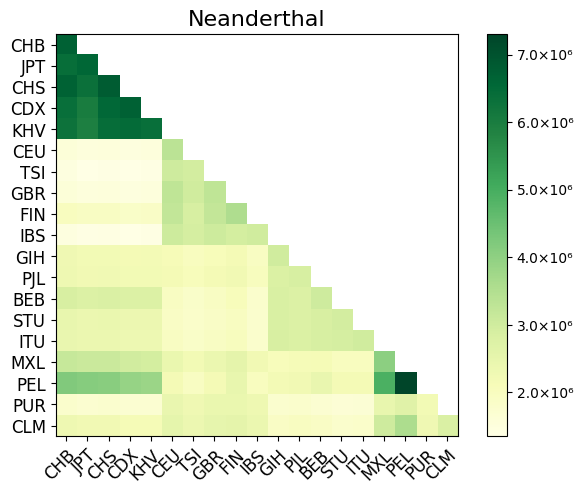

In [10]:
plot_comparisons(compared_hmm_nean, np.nanmin(compared_hmm_nean), np.nanmax(compared_hmm_nean), 'Neanderthal')

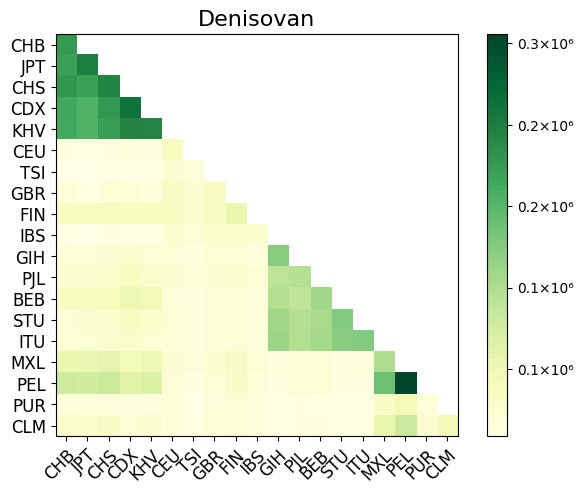

In [11]:
plot_comparisons(compared_hmm_den, np.nanmin(compared_hmm_den), np.nanmax(compared_hmm_den), 'Denisovan')

In [12]:
def summarize_pairwise_sharing(df, subpop_pair, exclude_zeros=False):
    vals = df[df['subpop_pair'] == subpop_pair]['value']
    
    if exclude_zeros:
        vals = vals[vals > 0]
    
    mean_val = np.mean(vals)
    std_val = np.std(vals, ddof=1)  # sample standard deviation
    
    # Convert to millions
    mean_million = mean_val / 1e6
    std_million = std_val / 1e6
    
    print(f"{subpop_pair}: {mean_million:.2f} ×10⁶ ± {std_million:.2f} ×10⁶")
    
    return mean_val, std_val

In [14]:
def get_distributions(archaic_type):
    input_dir = f"/users/akuntzle/data/akuntzle/hmmix_output/pairwise_comparisons_{archaic_type}"

    all_values = defaultdict(list)

    for fname in os.listdir(input_dir):
        filepath = os.path.join(input_dir, fname)

        # Match format like CLM_{ITU}.txt
        match_pairwise = re.match(r"^([A-Z]+)_\{([A-Z]+)\}\.txt$", fname)
        if match_pairwise:
            subpop1, subpop2 = match_pairwise.groups()
            pair_key = f"{subpop1}-{subpop2}"

            with open(filepath) as f:
                for line in f:
                    parts = line.strip().split("\t")
                    if len(parts) < 2:
                        continue
                    value = int(parts[2]) if len(parts) == 3 else 0
                    all_values[pair_key].append(value)
            continue

        # Match format like all_MXL.txt
        match_all = re.match(r"^all_([A-Z]+)\.txt$", fname)
        if match_all:
            subpop = match_all.group(1)
            pair_key = f"{subpop}-{subpop}"

            with open(filepath) as f:
                for line in f:
                    parts = line.strip().split("\t")
                    if len(parts) < 2:
                        continue
                    value = int(parts[2]) if len(parts) == 3 else 0
                    all_values[pair_key].append(value)

    # Make long-form DataFrame
    rows = []
    for pair, values in all_values.items():
        for v in values:
            rows.append((pair, v))

    df = pd.DataFrame(rows, columns=["subpop_pair", "value"])
    return df


The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


In [15]:
nean_shares = get_distributions('neanderthal')

In [16]:
summarize_pairwise_sharing(nean_shares, 'PEL-PEL')

PEL-PEL: 5.03 ×10⁶ ± 2.35 ×10⁶


(5025680.96744875, 2347318.569544089)

In [17]:
summarize_pairwise_sharing(nean_shares, 'PUR-PUR')

PUR-PUR: 1.57 ×10⁶ ± 1.10 ×10⁶


(1571663.3417590251, 1097250.3304477492)

In [18]:
summarize_pairwise_sharing(nean_shares, 'MXL-MXL')

MXL-MXL: 2.86 ×10⁶ ± 1.82 ×10⁶


(2859463.2648712005, 1819708.9500581846)

In [19]:
summarize_pairwise_sharing(nean_shares, 'CLM-CLM')

CLM-CLM: 1.97 ×10⁶ ± 1.26 ×10⁶


(1972846.824506929, 1255123.1539389826)

In [20]:
#This is means and standard deviations of within-population pairs
hmm_means = []
hmm_stds = []
ibd_means = []
ibd_stds = []
eur_ibd = []
for pop in sub_pops:
    comparisons = pd.read_csv(f'/users/akuntzle/data/akuntzle/hmmix_output/pairwise_comparisons_all/all_{pop}.txt',sep='\t', header=None,
                         names=['id1','id2','total_shared'])
    print(pop)
    archaic_mean = statistics.mean(comparisons['total_shared'])/(2*6_000_000_000)
    archaic_std = statistics.stdev(comparisons['total_shared'])/(2*6_000_000_000)
    IBD_mean = avg_ibd_share[f'{pop}_{pop}']
    IBD_std =std_ibd_share[f'{pop}_{pop}']
    
    hmm_means.append(archaic_mean)
    hmm_stds.append(archaic_std)
    ibd_means.append(IBD_mean)
    ibd_stds.append(IBD_std)
    print(f'Archaic mean: {archaic_mean}')
    print(f'Archaic std dev: {archaic_std}')
    print(f'IBD mean: {IBD_mean}')
    print(f'IBD std dev: {IBD_std}')
    print(f'Num IBD pairs: {ibd_num_pairs[f"{pop}_{pop}"]}')

FileNotFoundError: [Errno 2] No such file or directory: '/users/akuntzle/scratch/IBD_archaic_shared/pairwise_comparisons_hmmix/all_CHB.txt'